In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")

In [110]:
print("Shape of Dataset: ",df.shape)
df.head()

Shape of Dataset:  (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


### No Missing Values

In [121]:
df.isna().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [6]:
df.columns = df.columns.str.strip()

In [117]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')

### Theirs mild Class-Imbalance

In [53]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

#### Droping ID column as its not required

In [3]:
df = df.drop("loan_id", axis=1)

In [4]:
df.head(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


### => Split Train Test

In [7]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
df = pd.concat([X_train, y_train], axis=1)

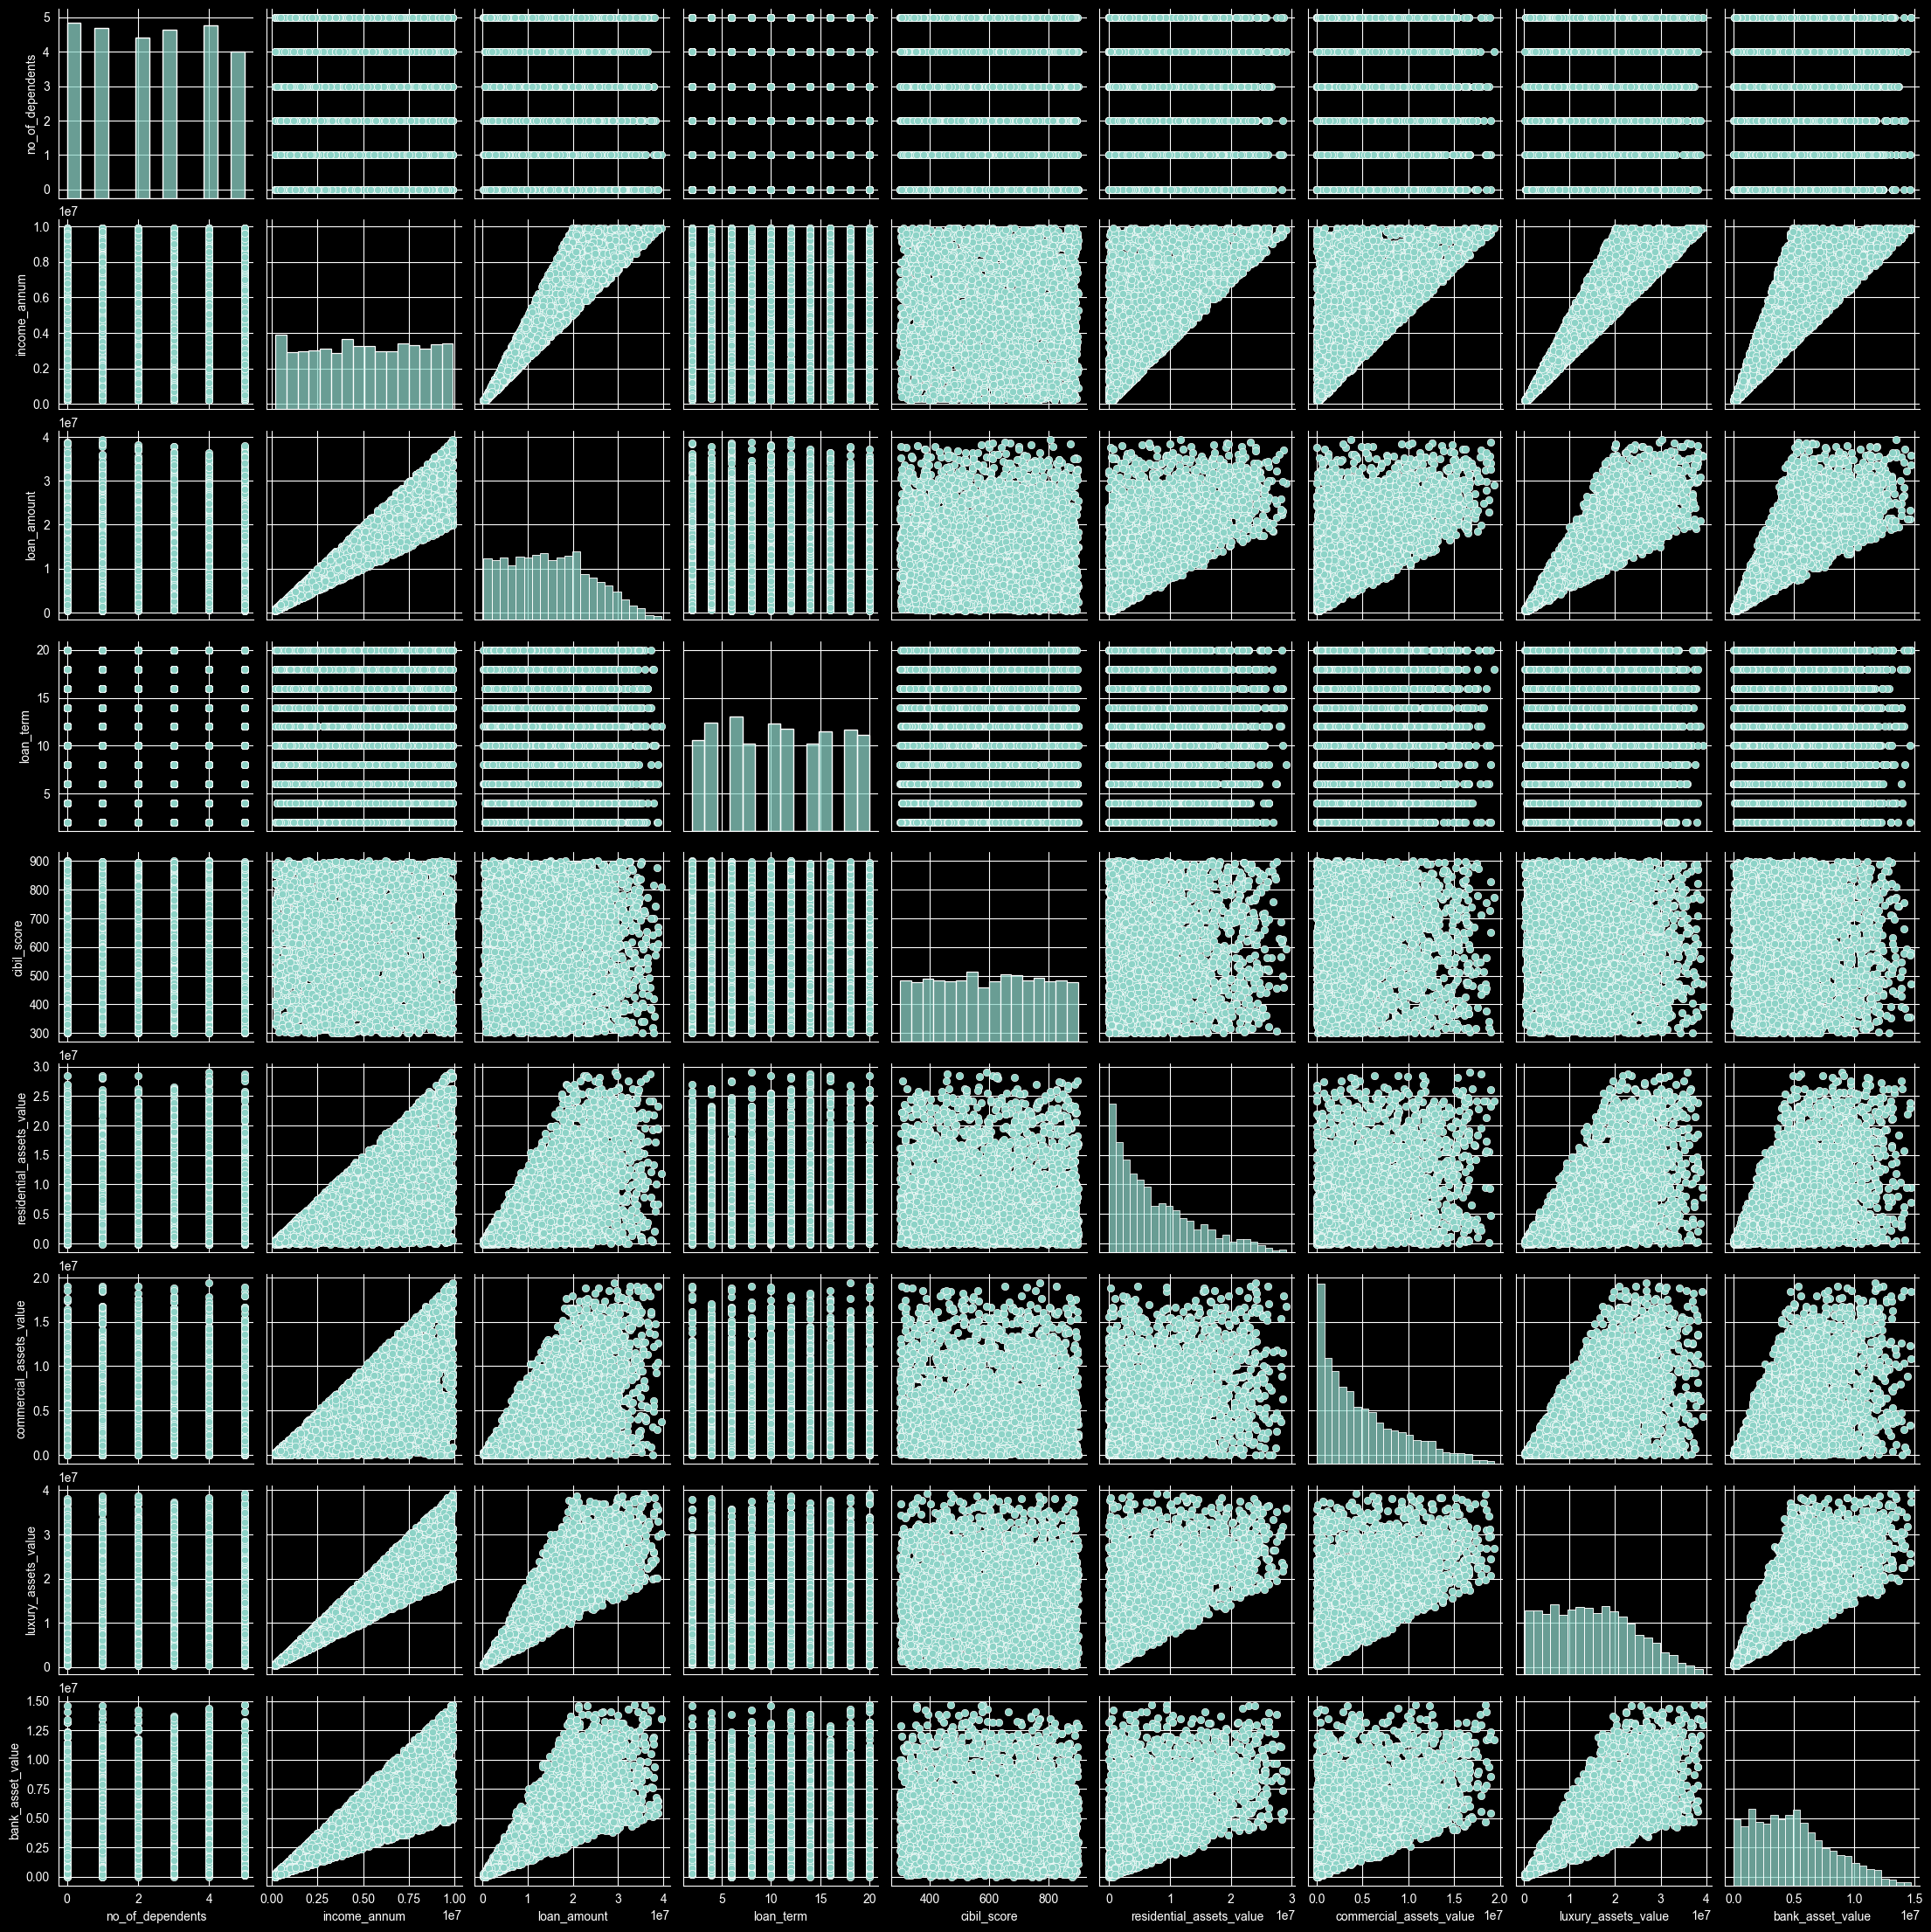

In [80]:
sns.pairplot(df)

## Column wise EDA

### 1) no_of_dependents

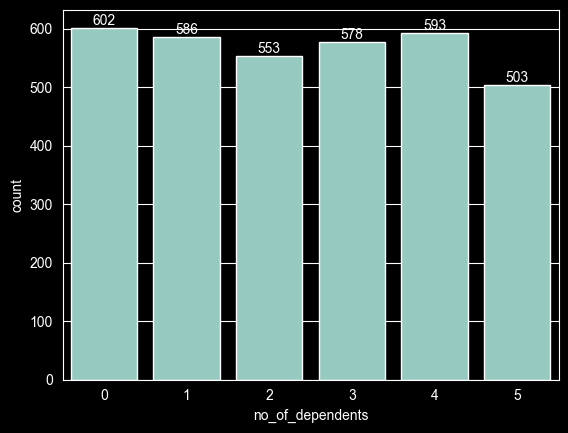

In [68]:
ax = sns.countplot(data=df, x="no_of_dependents")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 2) education

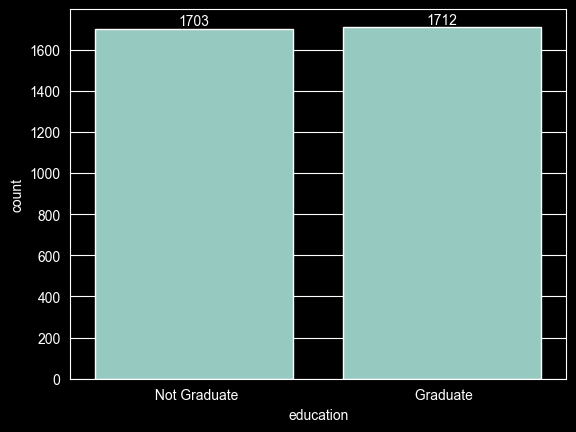

In [69]:
ax = sns.countplot(data=df, x="education")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 3) self_employed

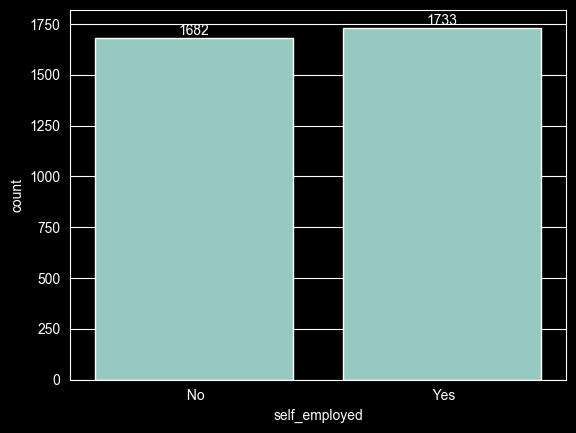

In [70]:
ax = sns.countplot(data=df, x="self_employed")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

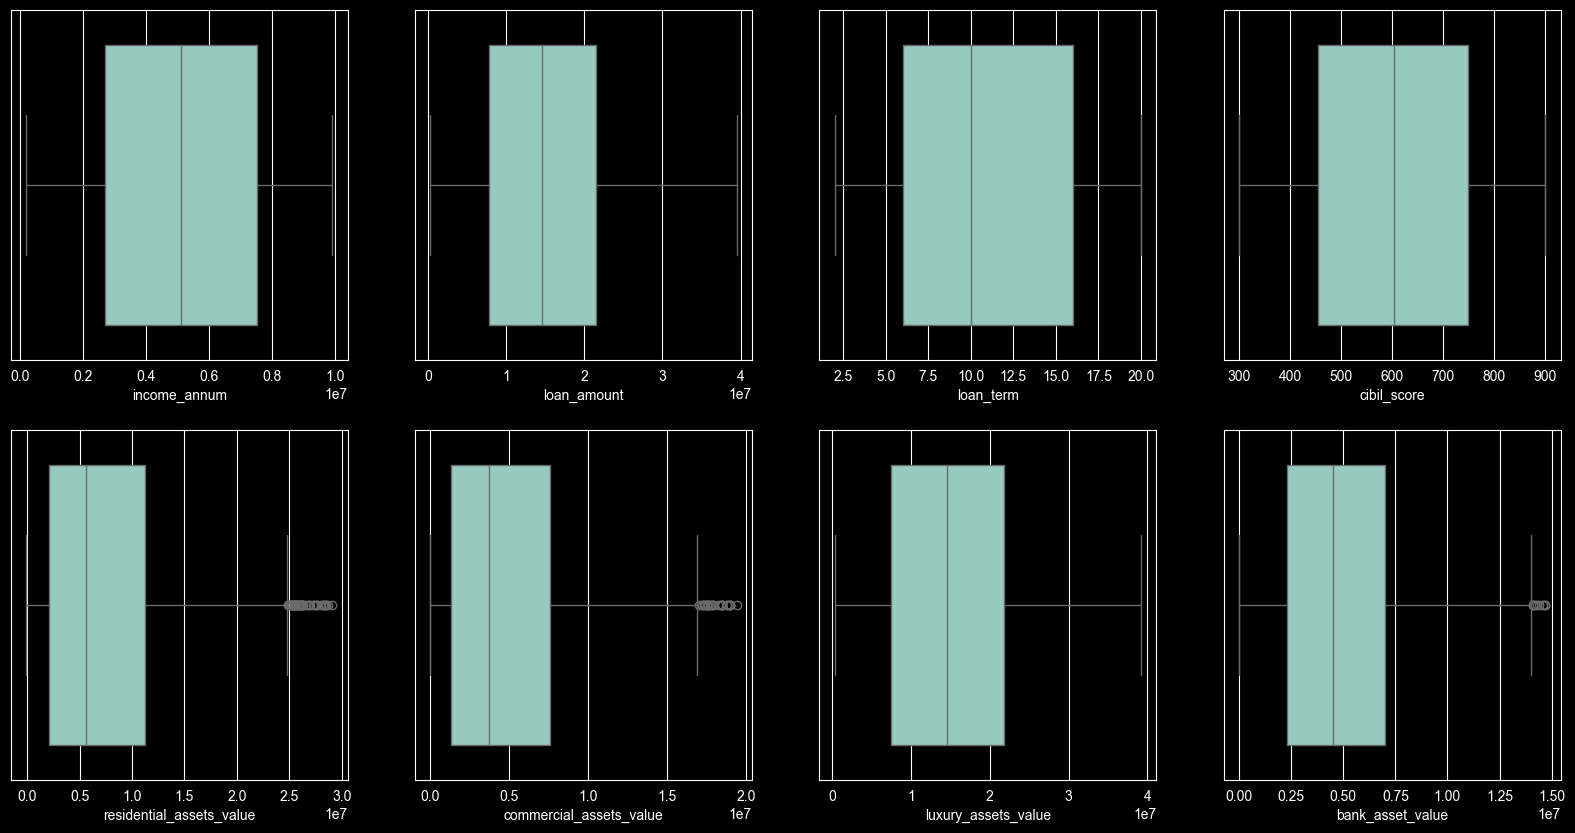

In [74]:
numeric_cols = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

fig, ax = plt.subplots(2, 4, figsize=(20, 10))

ax = ax.flatten()

for index, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=ax[index])

plt.show()

<Axes: xlabel=' loan_status', ylabel=' cibil_score'>

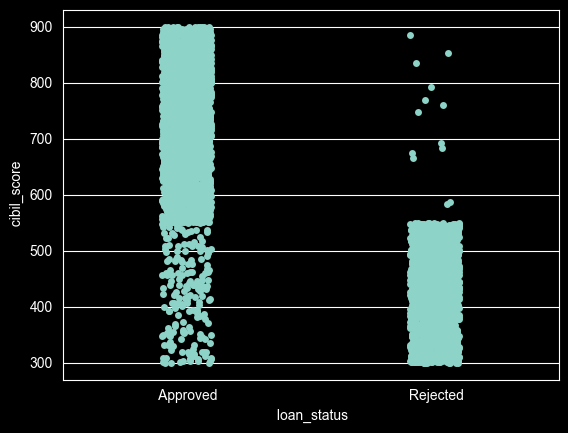

In [39]:
sns.stripplot(data=df, x=" loan_status", y=" cibil_score")

In [82]:
temp = df[(df['loan_status'] == 'Rejected') | (df['cibil_score'] > 600)]

In [86]:
temp.sample(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3390,4,Graduate,No,5800000,13500000,14,816,13800000,9300000,20400000,7900000,Approved
2219,3,Graduate,Yes,7800000,19600000,4,767,18100000,10500000,20500000,7700000,Approved
2046,1,Graduate,No,9700000,33900000,10,833,24600000,16200000,28300000,6600000,Approved
19,5,Graduate,No,6300000,14600000,12,652,10300000,3500000,23500000,5900000,Approved
245,1,Not Graduate,Yes,8000000,28100000,18,725,1900000,12800000,23000000,7500000,Approved


### Encoding Categorical Columns

In [9]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

In [10]:
encoded = ohe.fit_transform(df[['education', 'self_employed']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['education', 'self_employed']),
    index=df.index
)

In [11]:
encoded_df.head()

,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1675,0.0,1.0,1.0,0.0
1164,0.0,1.0,0.0,1.0
192,1.0,0.0,1.0,0.0
910,1.0,0.0,0.0,1.0
567,1.0,0.0,0.0,1.0


In [12]:
encoded_df.isna().sum()

education_ Graduate        0
education_ Not Graduate    0
self_employed_ No          0
self_employed_ Yes         0
dtype: int64

### Join it with main Dataframe

In [13]:
df = pd.concat([df.drop(['education', 'self_employed'], axis=1), encoded_df], axis=1)

In [14]:
df.isna().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
education_ Graduate         0
education_ Not Graduate     0
self_employed_ No           0
self_employed_ Yes          0
dtype: int64

In [15]:
df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1675,5,7900000,29900000,6,568,5800000,13900000,15900000,8700000,Approved,0.0,1.0,1.0,0.0
1164,0,9600000,34000000,12,710,23800000,10300000,38100000,7800000,Approved,0.0,1.0,0.0,1.0
192,1,800000,2900000,8,682,2200000,1100000,2900000,700000,Approved,1.0,0.0,1.0,0.0
910,2,4900000,13100000,18,754,8200000,3300000,16500000,7200000,Approved,1.0,0.0,0.0,1.0
567,5,3000000,11100000,12,441,8500000,2500000,7300000,2000000,Rejected,1.0,0.0,0.0,1.0


### Encoding Target feature

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(df['loan_status'])

In [17]:
X_train = df.drop("loan_status", axis=1)

In [18]:
X_train.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1675,5,7900000,29900000,6,568,5800000,13900000,15900000,8700000,0.0,1.0,1.0,0.0
1164,0,9600000,34000000,12,710,23800000,10300000,38100000,7800000,0.0,1.0,0.0,1.0
192,1,800000,2900000,8,682,2200000,1100000,2900000,700000,1.0,0.0,1.0,0.0
910,2,4900000,13100000,18,754,8200000,3300000,16500000,7200000,1.0,0.0,0.0,1.0
567,5,3000000,11100000,12,441,8500000,2500000,7300000,2000000,1.0,0.0,0.0,1.0


### Preprocess Test Data

In [19]:
# Transform test
test_encoded = ohe.transform(
    X_test[['education', 'self_employed']]
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['education', 'self_employed']),
    index=X_test.index
)

X_test = pd.concat(
    [
        X_test.drop(['education', 'self_employed'], axis=1),
        test_encoded_df
    ],
    axis=1
)

y_test = le.transform(y_test)

In [20]:
X_test.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1703,5,5400000,19700000,20,423,6500000,10000000,15700000,7300000,1.0,0.0,1.0,0.0
1173,2,5900000,14000000,8,599,4700000,9500000,17800000,6700000,1.0,0.0,1.0,0.0
308,3,9600000,19900000,14,452,4200000,16200000,28500000,6600000,1.0,0.0,1.0,0.0
1322,2,6200000,23400000,8,605,10000000,10800000,21800000,9200000,1.0,0.0,1.0,0.0
3271,3,5800000,14100000,12,738,11700000,4400000,15400000,8400000,0.0,1.0,0.0,1.0


## Scale Numerical Features

In [21]:
from sklearn.preprocessing import RobustScaler

cols_to_scale = [
    "income_annum",
    "loan_amount",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]


scaler = RobustScaler()

# Fit on train, transform train
X_train[cols_to_scale] = scaler.fit_transform(
    X_train[cols_to_scale]
)

# Transform test using same scaler
X_test[cols_to_scale] = scaler.transform(
    X_test[cols_to_scale]
)

In [102]:
X_train.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1675,5.0,0.583333,1.120879,6.0,-0.119250,0.021978,1.632,0.090909,0.893617,1.0,0.0,0.0,1.0
1164,0.0,0.937500,1.421245,12.0,0.364566,2.000000,1.056,1.643357,0.702128,0.0,1.0,1.0,0.0
192,1.0,-0.895833,-0.857143,8.0,0.269165,-0.373626,-0.416,-0.818182,-0.808511,1.0,0.0,1.0,0.0
910,2.0,-0.041667,-0.109890,18.0,0.514480,0.285714,-0.064,0.132867,0.574468,0.0,1.0,1.0,0.0
567,5.0,-0.437500,-0.256410,12.0,-0.551959,0.318681,-0.192,-0.510490,-0.531915,1.0,0.0,1.0,0.0


In [22]:
# Combine features and target for training set
train_df = pd.concat([X_train, y_train], axis=1)

# Combine features and target for test set
test_df = pd.concat([X_test, y_test], axis=1)

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [ ]:
train_df.to_csv("train_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

In [24]:
train_df = X_train.copy()
train_df['target'] = y_train

test_df = X_test.copy()
test_df['target'] = y_test

In [25]:
train_df.to_csv("train_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

# Apply Cross Validation to Evaluate models

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "GaussianNB": GaussianNB(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100)
}

In [145]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='accuracy'
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

results = pd.DataFrame(results)

print(results.sort_values(
    by="Mean Accuracy",
    ascending=False
))

                    Model  Mean Accuracy   Std Dev
3  RandomForestClassifier       0.975403  0.007373
2              GaussianNB       0.934700  0.014541
0     Logistic Regression       0.919180  0.011394
1                     KNN       0.814056  0.017175


In [149]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [150]:
y_pred = lr.predict(X_test)

In [151]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       536
           1       0.88      0.87      0.88       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854



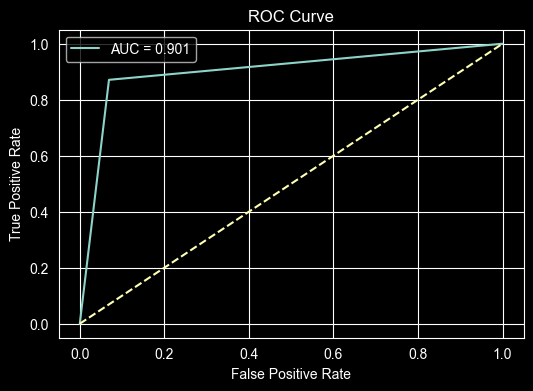

In [152]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()